In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4])
print(arr)
arr2 = arr[1:3]


In [ ]:
print(arr[1:3]) 

In [ ]:
arr = np.array([
    [1,2,3],
    [4,5,6]
])

In [ ]:
print(arr[0,2]) 

In [ ]:
arr = np.array([10,20,30,40])

print(arr.sum())
print(arr.mean())
print(arr.max())
print(arr.min())

In [ ]:
arr = np.array([1,2,3,4,5,6])

reshaped = arr.reshape(1,6)
print(reshaped)

In [ ]:
np.zeros((2,3))
np.ones((2,3))
np.arange(0,10,2)
np.linspace(0,1,5)

In [ ]:
weights = np.zeros(3)

In [ ]:
print(weights)

In [ ]:
X = np.linspace(0, 10, 5)  

In [ ]:
X

In [ ]:
# ```python
import pandas as pd

# Method 1: From dictionary (like creating SAS dataset inline)
data = {
    'customer_id': [101, 102, 103, 104],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'balance': [5000, 3500, 7200, 2100],
    'account_type': ['Checking', 'Savings', 'Checking', 'Savings']
}
df = pd.DataFrame(data)
print(df)

In [ ]:
df['monthly_interest'] = df['balance'] * 0.02 

In [ ]:
df['risk_level'] = df['balance'].apply(lambda x: 'High' if x > 5000 else 'Low')

In [ ]:
import numpy as np
df['risk_level'] = np.where(df['balance'] > 5000, 'High', 'Low')

In [ ]:
high_balance = df[df['balance'] > 3000]
print(high_balance)

In [ ]:
premium_customers = df[(df['balance'] > 5000) & (df['account_type'] == 'Checking')]

In [ ]:
### Grouping & Aggregation (PROC SUMMARY / GROUP BY)

# ```python
# Like PROC SUMMARY or SQL GROUP BY
account_stats = df.groupby('account_type').agg({
    'balance': ['mean', 'sum', 'count', 'min', 'max'],
    'customer_id': 'count'
}).round(2)

print(account_stats)

# Multiple aggregations with custom names
summary = df.groupby('account_type').agg(
    total_balance=('balance', 'sum'),
    avg_balance=('balance', 'mean'),
    num_customers=('customer_id', 'count'),
    max_balance=('balance', 'max')
)

In [ ]:
summary

In [ ]:
import random

die = random.choice(["1","2","3","4","5","6"])

print(die)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
 
# Load a real medical dataset — features have very different scales
X, y = load_breast_cancer(return_X_y=True)
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
 
# --- WITHOUT scaling ---
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))
print(f'Accuracy WITHOUT scaling: {acc_raw:.2%}')  # Typically ~62%
 
# --- WITH StandardScaler (transforms each feature to mean=0, std=1) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn mean & std from TRAIN only
X_test_scaled  = scaler.transform(X_test)        # Apply same transformation to TEST
 
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))
print(f'Accuracy WITH scaling:    {acc_scaled:.2%}')  # Typically ~96%
 
# Inspect what the scaler learned
print(f'Original mean of feature 0: {X_train[:,0].mean():.2f}')
print(f'Scaled  mean of feature 0: {X_train_scaled[:,0].mean():.4f}')  # ~0.0
print(f'Original std  of feature 0: {X_train[:,0].std():.2f}')
print(f'Scaled  std  of feature 0:  {X_train_scaled[:,0].std():.4f}')  # ~1.0


In [ ]:
# Python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
 
# Generate normally distributed data: mean=170cm, std=10cm (heights)
np.random.seed(42)
heights = np.random.normal(loc=170, scale=10, size=1000)
 
print(f'Mean:   {heights.mean():.1f} cm')
print(f'Std dev: {heights.std():.1f} cm')
 
# How many students are within 1, 2, 3 standard deviations?
within_1sigma = np.sum(np.abs(heights - heights.mean()) <= heights.std()) / len(heights)
within_2sigma = np.sum(np.abs(heights - heights.mean()) <= 2*heights.std()) / len(heights)
print(f'Within 1σ: {within_1sigma:.1%}')  # Should be ~68%
print(f'Within 2σ: {within_2sigma:.1%}')  # Should be ~95%
 
# Test if your data is normally distributed
stat, p_value = stats.normaltest(heights)
print(f'Normality test: p = {p_value:.4f}')
print('Data is NORMAL' if p_value > 0.05 else 'Data is NOT NORMAL')
# If p > 0.05: we cannot reject the hypothesis that data is normal


In [ ]:
within_3sigma = np.sum(np.abs(heights - heights.mean()) <= 3*heights.std()) / len(heights)
print(f'Within 2σ: {within_3sigma:.1%}')  # Should be ~99.7%

In [ ]:
import numpy as np
from scipy import stats
 
# Simulate right-skewed income data (most people earn moderately, few earn a lot)
np.random.seed(0)
incomes = np.random.exponential(scale=50000, size=1000) + 20000
 
print(f'Original  — Mean: {np.mean(incomes):>10,.0f}')
print(f'Original  — Median: {np.median(incomes):>8,.0f}')
print(f'Original  — Skewness: {stats.skew(incomes):.2f}')  # High = very skewed
 
# Apply log transformation to reduce skew
# np.log1p(x) = log(1 + x) — safe even if some values are 0
log_incomes = np.log1p(incomes)
 
print(f'Log-trans — Skewness: {stats.skew(log_incomes):.2f}')  # Should be near 0
 
# The transformation pipeline in practice:
# 1. Apply log to target variable before training
# 2. Train your regression model on log(income)
# 3. When predicting, apply np.expm1() to reverse the transform
# np.expm1(x) = exp(x) - 1   (the exact inverse of log1p)
original_scale_prediction = np.expm1(log_incomes[:5])
print('Reversed back to original scale:', original_scale_prediction.round(0))


In [ ]:
import numpy as np
from scipy import stats
 
# Relationship between study hours and exam scores
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
exam_scores = np.array([45, 52, 58, 61, 70, 74, 79, 83, 89, 92])
 
r, p_value = stats.pearsonr(study_hours, exam_scores)
 
print(f'Pearson r:  {r:.3f}')      # 0.996 — almost perfect positive correlation
print(f'P-value:    {p_value:.6f}') # Very small — relationship is statistically significant
 
# Interpreting r values
def interpret(r):
    a = abs(r)
    direction = 'positive' if r > 0 else 'negative'
    if a < 0.2:   strength = 'negligible'
    elif a < 0.4: strength = 'weak'
    elif a < 0.6: strength = 'moderate'
    elif a < 0.8: strength = 'strong'
    else:         strength = 'very strong'
    return f'{strength} {direction} correlation'
 
print(f'Interpretation: {interpret(r)}')
 
# Spearman correlation — use when relationship is monotonic but not linear
# (e.g. rankings, ordinal data, or heavily skewed variables)
rho, p_sp = stats.spearmanr(study_hours, exam_scores)
print(f'Spearman rho: {rho:.3f}')   # More robust to outliers


             size_sqft  num_rooms  age_years  distance_km  price
size_sqft         1.00       0.95       0.07         0.02   0.60
num_rooms         0.95       1.00       0.04         0.03   0.59
age_years         0.07       0.04       1.00        -0.02  -0.49
distance_km       0.02       0.03      -0.02         1.00  -0.46
price             0.60       0.59      -0.49        -0.46   1.00


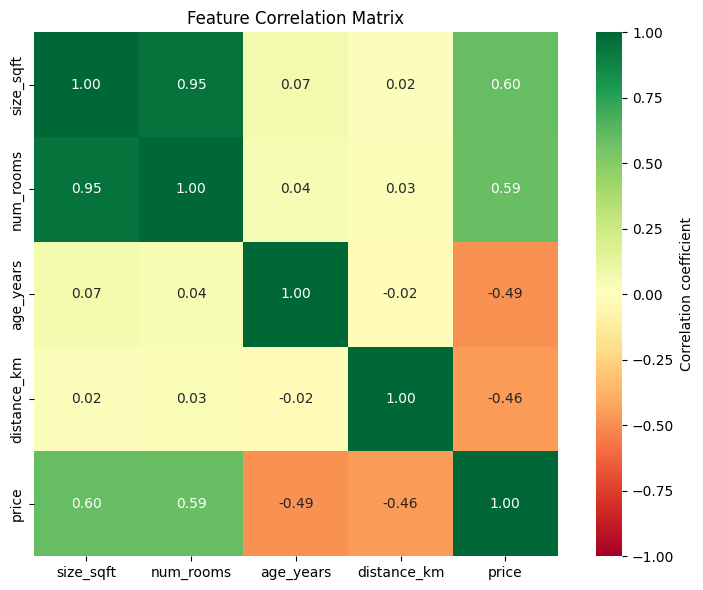

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
# Build a realistic housing dataset
np.random.seed(42)
n = 300
size_sqft  = np.random.uniform(500, 3000, n)
num_rooms  = (size_sqft / 400 + np.random.normal(0, 0.5, n)).round()  # correlated with size
age_years  = np.random.uniform(1, 50, n)
distance_km= np.random.uniform(1, 30, n)
price      = 50*size_sqft - 2000*age_years - 3000*distance_km + np.random.normal(0, 20000, n)
 
df = pd.DataFrame({'size_sqft':size_sqft, 'num_rooms':num_rooms,
                   'age_years':age_years,  'distance_km':distance_km, 'price':price})
 
# Correlation matrix
corr = df.corr().round(2)
print(corr)
 
# Visualise as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, square=True, fmt='.2f',
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
# Look at the 'price' row — size_sqft and num_rooms will be highest
# Look at size_sqft vs num_rooms — high correlation = potential multicollinearity


In [15]:
corr


,size_sqft,num_rooms,age_years,distance_km,price
size_sqft,1.00,0.95,0.07,0.02,0.60
num_rooms,0.95,1.00,0.04,0.03,0.59
age_years,0.07,0.04,1.00,-0.02,-0.49
distance_km,0.02,0.03,-0.02,1.00,-0.46
price,0.60,0.59,-0.49,-0.46,1.00
